In [ ]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, InputLayer, Conv1D, ReLU, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings("ignore")

# import splitfolders

import cv2
import dlib
import imutils
from imutils import face_utils
import numpy as np
from PIL import Image
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.preprocessing.image import array_to_img


import pkg_resources


In [ ]:
STEP_TRAIN=32
STEP_VALID=10

MODEL_VER="morig"  ## With fmask detected ones in Green rectangles to the face while not ones with Red
                ## Not zoomed

MODEL_DIR="./models/"+MODEL_VER+"/"


In [ ]:
main_dir = './dataset/input'
output_dir = './dataset/output'

splitfolders.ratio(main_dir, output=output_dir, seed=1337, ratio=(.7,.2,.1))


Copying files: 5787 files [00:38, 149.58 files/s]


In [ ]:
def normalize8(I):
  mn = I.min()
  mx = I.max()

  mx -= mn

  I = ((I - mn)/mx) * 255
  return I.astype(np.uint8)

In [ ]:

face_detector = dlib.get_frontal_face_detector()
#predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")  
# Load the custom cascade




def ourImagePreprocessingFn(img):
    reqSize=img.shape    
    
    #print("Inside ourImagePreprocessingFn:",img.shape, img.dtype)
    

    img1 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    #print("Img1:",img1.shape, img1.dtype)
    #plt.imshow(img1)
    #plt.show()

    #print(reqSize)
    img_gray=cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)    
    #print(img_gray.shape, img_gray.dtype)    
    #plt.imshow(img_gray)
    #plt.show()    
    isFaceMaskFound=False
    frame1=None
    #img_gray.reshape((img_gray.shape[0],img_gray.shape[1],1))
    #rects = face_detector(img_gray, 1)
    #print(img_gray.dtype,"Rects:" ,len(rects))
    fmask_cascade=cv2.CascadeClassifier(r'C:/Users/RRG/neuralnw/data/fmask.xml') 
    
    rects = fmask_cascade.detectMultiScale(img_gray, scaleFactor=1.2, minNeighbors=6)
    #https://github.com/rohitnairkp/Custom-Haar-Cascade-Mask-Classifier
    if(len(rects) > 0):
        isFaceMaskFound=True
        
    #print("FaceMask Found:", isFaceMaskFound)
        
    if isFaceMaskFound == True:    
        for (x, y, width, height) in rects:     
            # We draw a green rectangle around
            # every recognized sign
            cv2.rectangle(img_rgb, (x, y), 
                          (x + height, y + width), 
                          (0, 255, 0), 5)        

    #gray.reshape((img_gray.shape[0],img_gray.shape[1],1))
    rects = face_detector(img_gray, 1)
    #print(gray.dtype,"Rects:" ,len(rects))
    for rect in rects:
        # These are the specific changes that I want to make to face.top, face.left etc..
        top = max(0, rect.top())
        bottom = min(rect.bottom(), img_gray.shape[0])
        left = max(0, rect.left())
        right = min(rect.right(), img_gray.shape[1])
        # Finally, I have to pass this face object into the encode_faces function that I have created
        #encoding = encode_faces(image, face) 
        #print(top,bottom,left,right)
        frame1 = img_rgb.astype(np.uint8)[top:bottom, left:right]
        
    if(frame1 is None):
        # Initialize arguments for the filter
        top = int(0.05 * img_gray.shape[0])  # shape[0] = rows
        bottom = top
        left = int(0.05 * img_gray.shape[1])  # shape[1] = cols
        right = left   
        
        borderType = cv2.BORDER_CONSTANT
        value = [255,0,0]
        dst = cv2.copyMakeBorder(img_rgb, top, bottom, left, right, borderType, None, value)        
          
        frame1 =dst
    
    frame1=cv2.resize(frame1, (reqSize[0],reqSize[1]))
        
    #plt.imshow(frame1)
    #plt.show()
    #print(frame1.shape)
    #print("Resized:",type(frame1),frame1.shape, frame1.dtype)    
    #image_tensor = tf.convert_to_tensor(frame1)
    #float_image_tensor = tf.image.convert_image_dtype(image_tensor,tf.float32)
    #print(type(float_image_tensor),float_image_tensor.shape, float_image_tensor.dtype)    

    #img=frame1
    
    return (img_to_array(frame1))

In [ ]:
#train_datagen = ImageDataGenerator()
#train_datagen = ImageDataGenerator(preprocessing_function = ourImagePreprocessingFn)
train_datagen = ImageDataGenerator(
                        preprocessing_function = ourImagePreprocessingFn,   
                         width_shift_range = 0.005,
                         height_shift_range = 0.005,
                         rotation_range = 0,
                         horizontal_flip = True,
                        rescale=1.0/255)







In [ ]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_dir,'train'),
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)


Found 4050 images belonging to 3 classes.


In [ ]:
target_class_names = []
classLabelsDict={}
for key in train_generator.class_indices:
    target_class_names.append(key)
    
for i in range(len(target_class_names)):
    classLabelsDict[i]=target_class_names[i]

print(classLabelsDict)    
    
print(target_class_names)

{0: 'partial_mask', 1: 'with_mask', 2: 'without_mask'}
['partial_mask', 'with_mask', 'without_mask']


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    os.path.join(output_dir,'val'),
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=31,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

Found 1157 images belonging to 3 classes.





validation_generator = train_datagen.flow_from_directory(os.path.join(output_dir,'val'),
                                                        target_size=(224, 224),
                                                        batch_size=32,
                                                        class_mode='categorical',
                                                        shuffle=True,
                                                        seed=42) # set as validation data


In [ ]:


test_generator = train_datagen.flow_from_directory(
    os.path.join(output_dir,'test'),
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=1,
    class_mode="categorical",
    shuffle=False,
    seed=42
)

Found 580 images belonging to 3 classes.


In [ ]:
def sample_from_generator(gen, numOfTotalFiles):
    
    print("Inside sample_from_generator start: To fetch ",numOfTotalFiles, " files")
    
    cur_x, cur_y = next(gen)
    input_shape = list(cur_x.shape)[1:]
    num_classes = cur_y.shape[1]
    batch_size = len(cur_x)

    numOfFileFecthed=0
    numOfBatchFilesFetched=batch_size

    i=0
    #print("** sample_from_generator iteration:",i+1, numOfBatchFilesFetched, numOfFileFecthed)
    

    X_sample = np.zeros([numOfTotalFiles] + list(input_shape))
    Y_sample = np.zeros((numOfTotalFiles, num_classes))
    
    numOfBatchFilesFetched=len(cur_x)
   
    if(numOfBatchFilesFetched >0):
        X_sample[numOfFileFecthed:numOfFileFecthed + (numOfBatchFilesFetched)] = cur_x
        Y_sample[numOfFileFecthed:numOfFileFecthed + (numOfBatchFilesFetched)] = cur_y

        numOfFileFecthed   +=numOfBatchFilesFetched



    print("sample_from_generator iteration:",i+1, numOfBatchFilesFetched, numOfFileFecthed)
    
    
    for i in range(1, numOfTotalFiles, batch_size):
        if(numOfFileFecthed < numOfTotalFiles):
    
            cur_x, cur_y = next(gen)
        
            numOfBatchFilesFetched=len(cur_x)        
            #print("*** sample_from_generator iteration:",i+1, numOfBatchFilesFetched, numOfFileFecthed)
        
            if(numOfBatchFilesFetched >0):
                X_sample[numOfFileFecthed:numOfFileFecthed + (numOfBatchFilesFetched)] = cur_x
                Y_sample[numOfFileFecthed:numOfFileFecthed + (numOfBatchFilesFetched)] = cur_y

                numOfFileFecthed   +=numOfBatchFilesFetched


        
            print("sample_from_generator iteration:",i+1, numOfBatchFilesFetched, numOfFileFecthed)
            
            
        
    return X_sample, Y_sample

In [ ]:
model = keras.Sequential([
    # Input Layer
    keras.layers.Conv2D(input_shape=(224,224,3),filters=32,kernel_size=(3,3),activation='relu'),
    #BatchNormalization(),
    keras.layers.MaxPooling2D(),
    #Dropout(0.2),
    
    # Hidden Layer
    keras.layers.Conv2D(input_shape=(224,224,3),filters=64,kernel_size=(3,3),activation='relu'),
    #BatchNormalization(),
    keras.layers.MaxPooling2D(),
    #Dropout(0.2),
    
    keras.layers.Conv2D(input_shape=(224,224,3),filters=128,kernel_size=(3,3),activation='relu'),
    #BatchNormalization(),
    keras.layers.MaxPooling2D(),
    #Dropout(0.2),
    
    keras.layers.Flatten(),
    keras.layers.Dense(128),
    keras.layers.Activation('relu'),
    #Dropout(0.4),
    
    # Output Layer
    keras.layers.Dense(3),
    keras.layers.Activation('softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 111, 111, 32)     0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 54, 54, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 26, 26, 128)     

In [ ]:
logdir = os.path.join(MODEL_DIR+'logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)
checkpoint_path = MODEL_DIR+'epoch{epoch:02d}-loss{val_loss:.2f}.hdf5'
checkpoint_dir = os.path.dirname(checkpoint_path)
#checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_acc',save_best_only=True, save_freq='epoch')


checkpoint_callback =tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_acc',mode="max",verbose=1,save_best_only=True, save_freq='epoch')

early_stopping = keras.callbacks.EarlyStopping(monitor='val_acc',patience=3)


In [ ]:
#STEP_SIZE_TRAIN=train_set.n//train_set.batch_size
#print(STEP_SIZE_TRAIN)


sample_generator = train_datagen.flow_from_directory(
    os.path.join(output_dir,'samplegen'),
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
    seed=42
)

X,y=sample_from_generator(sample_generator,len(sample_generator.filenames))

#print("X:",X.shape,y.shape)


Found 11 images belonging to 3 classes.
Inside sample_from_generator start: To fetch  11  files
sample_from_generator iteration: 1 11 11


X[ 0 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


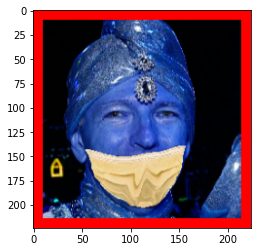

./models/morig/6.jpg
X[ 1 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


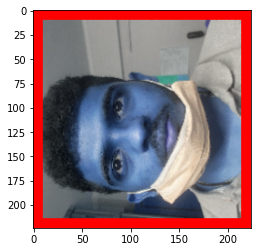

./models/morig/712.jpg
X[ 2 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


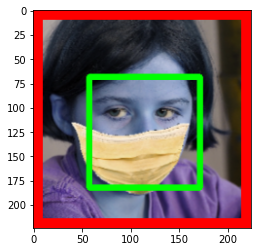

./models/morig/9.jpg
X[ 3 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


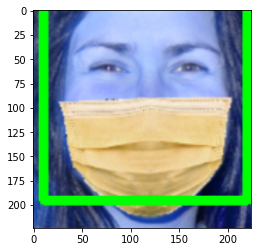

./models/morig/1.jpg
X[ 4 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


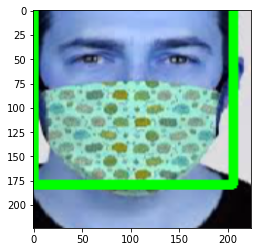

./models/morig/121.jpg
X[ 5 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


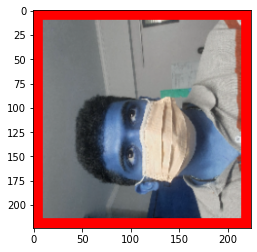

./models/morig/711.jpg
X[ 6 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


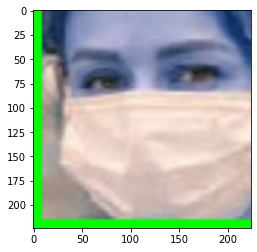

./models/morig/811.jpg
X[ 7 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


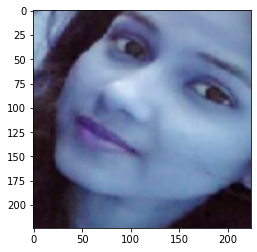

./models/morig/15.jpg
X[ 8 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


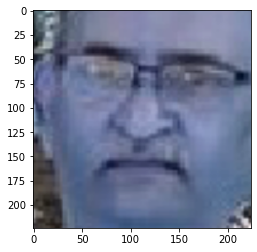

./models/morig/5.jpg
X[ 9 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


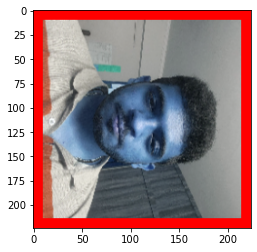

./models/morig/713.jpg
X[ 10 ]: <class 'numpy.ndarray'> (224, 224, 3) float64
<class 'numpy.ndarray'> (224, 224, 3) uint8


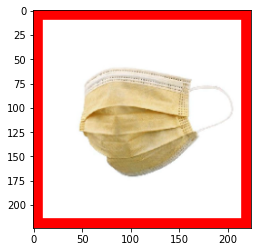

./models/morig/fmask.jpg


In [ ]:
for i in range(len(X)):
    print("X[",i,"]:",type(X[i]),X[i].shape,X[i].dtype)
    
    
    j = cv2.normalize(X[i], None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    
    #j=img1.astype(np.uint8)
    print(type(j),j.shape,j.dtype)
    
    #cv2.imwrite("customimg.jpg", X[i],cv2.cvtColor(X[i], cv2.COLOR_RGB2BGR),dtype='float32')
    #cv2.imwrite("customimg.jpg", j)
    plt.imshow(array_to_img(j))
    plt.show()
    imgFName=sample_generator.filenames[i]
    l1=imgFName.split(os.path.sep,1)[1]
    
    imgFName=MODEL_DIR+l1
    print(imgFName)

    cv2.imwrite(imgFName, j)


In [ ]:
history=model.fit(train_generator,
                    steps_per_epoch = (train_generator.samples // 32),
                    validation_data = validation_generator,
                    validation_steps = validation_generator.samples // 32,
                    epochs = 20,                  
                    #steps_per_epoch=STEP_SIZE_TRAIN,
                    workers=-1, 
                    use_multiprocessing=True,
                    callbacks=[tensorboard_callback, checkpoint_callback,early_stopping])



Epoch 1/20
126/126 [==============================] - ETA: 0s - loss: 0.4597 - acc: 0.8407
Epoch 00001: val_acc improved from -inf to 0.93011, saving model to ./models/morig\epoch01-loss0.23.hdf5
126/126 [==============================] - 484s 4s/step - loss: 0.4597 - acc: 0.8407 - val_loss: 0.2300 - val_acc: 0.9301
Epoch 2/20
126/126 [==============================] - ETA: 0s - loss: 0.2203 - acc: 0.9238
Epoch 00002: val_acc improved from 0.93011 to 0.93369, saving model to ./models/morig\epoch02-loss0.18.hdf5
126/126 [==============================] - 462s 4s/step - loss: 0.2203 - acc: 0.9238 - val_loss: 0.1828 - val_acc: 0.9337
Epoch 3/20
126/126 [==============================] - ETA: 0s - loss: 0.1694 - acc: 0.9457
Epoch 00003: val_acc improved from 0.93369 to 0.95699, saving model to ./models/morig\epoch03-loss0.15.hdf5
126/126 [==============================] - 464s 4s/step - loss: 0.1694 - acc: 0.9457 - val_loss: 0.1468 - val_acc: 0.9570
Epoch 4/20
126/126 [====================

In [ ]:
print(history.history.keys())
accuracy = history.history['acc']
val_accuracy = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


Text(0.5, 1.0, 'Training and validation accuracy')

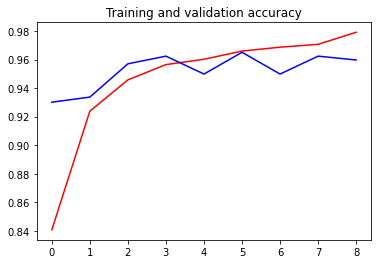

In [ ]:
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'r', label = 'Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label = 'Validation accuracy')
plt.title('Training and validation accuracy')

Text(0.5, 1.0, 'Training and validation loss')

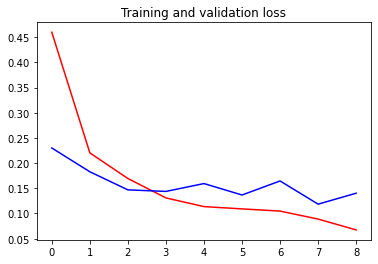

In [ ]:
epochs = range(len(accuracy))
plt.plot(epochs, loss, 'r', label = 'Training loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation loss')
plt.title('Training and validation loss')

In [ ]:

test_score = model.evaluate_generator(test_generator, validation_generator.samples // 32)

print("[INFO] accuracy: {:.2f}%".format(test_score[1] * 100)) 

print("[INFO] Loss: ",test_score[0])

[INFO] accuracy: 97.22%
[INFO] Loss:  0.05631538853049278


In [ ]:
test_generator.reset()
testPreds=model.predict_generator(test_generator,
steps=len(test_generator.filenames),
verbose=1)

580/580 [==============================] - 45s 77ms/step


In [ ]:
predicted_test_class_indices=np.argmax(testPreds,axis=1)
#print(predicted_class_indices)

test_predictions = [classLabelsDict[k] for k in predicted_test_class_indices]
y_truth= [classLabelsDict[k] for k in test_generator.classes]

In [ ]:
filenames=test_generator.filenames
results=pd.DataFrame({"Filename":filenames,
                      "Predictions":test_predictions})
#print(filenames)
resultsFName=MODEL_DIR+"results.csv"
results.to_csv(resultsFName,index=False)

Test Confusion Matrix


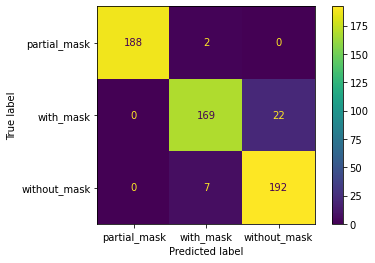

In [ ]:
print('Test Confusion Matrix')
cm=confusion_matrix(y_truth, test_predictions,labels=target_class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=target_class_names)
disp.plot()
plt.show()

In [ ]:
print(classification_report(y_truth, test_predictions))

              precision    recall  f1-score   support

partial_mask       1.00      0.99      0.99       190
   with_mask       0.95      0.88      0.92       191
without_mask       0.90      0.96      0.93       199

    accuracy                           0.95       580
   macro avg       0.95      0.95      0.95       580
weighted avg       0.95      0.95      0.95       580



The function save() saves the following features:

The architecture of the model.
Weights of the model.
Training configuration.
State of the optimizer.

In [ ]:
SaveModelAs="FaceMask_Kaggle_"+MODEL_VER
H5_MODEL=MODEL_DIR+SaveModelAs+".h5"
H5_WEIGHTS_MODEL=MODEL_DIR+SaveModelAs+"_wts.h5"

JSON_MODEL=MODEL_DIR+SaveModelAs+".json"

In [ ]:
model.save(H5_MODEL)

The architecture is saved as a JSON file or a YAML (Not Allowed owing to security) file. Look at the syntax below:

In [ ]:
from keras.models import model_from_json

save_model_json = model.to_json()
with open(JSON_MODEL, "w") as json_file:
    json_file.write(save_model_json )

In [ ]:
model.save_weights(H5_WEIGHTS_MODEL)


In [ ]:
from keras.models import load_model
model_new = load_model(H5_MODEL)

In [ ]:
facemask_kaggle_datagen = ImageDataGenerator(
                        preprocessing_function = ourImagePreprocessingFn)

facemask_kaggle_generator = facemask_kaggle_datagen.flow_from_directory(
    os.path.join(output_dir,'facemask_kaggle'),
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=1,
    classes=['FaceMask_Kaggle_test'],
    class_mode=None,
    shuffle=False,
    seed=42
)
facemask_kaggle_generator.reset()
facemask_kaggle_preds=model_new.predict_generator(facemask_kaggle_generator,
steps=len(facemask_kaggle_generator.filenames),
verbose=1)

Found 660 images belonging to 1 classes.
660/660 [==============================] - 43s 66ms/step


In [ ]:

predicted_fm_kaggle_test_class_indices=np.argmax(facemask_kaggle_preds,axis=1)

predictions_fm_kaggle_test = [classLabelsDict[k] for k in predicted_fm_kaggle_test_class_indices]

In [ ]:
filenames=facemask_kaggle_generator.filenames
filenames = [sub.replace('\\', '/') for sub in facemask_kaggle_generator.filenames]


In [ ]:


results=pd.DataFrame({"img_path":filenames,
                      "label":predictions_fm_kaggle_test})
#print(filenames)
resFName=MODEL_DIR+"FaceMask_Kaggle_test_results_"+MODEL_VER+".csv"
#resFName=MODEL_DIR+"FaceMask_Kaggle_test_results.csv"
results.to_csv(resFName,index=False)

Load Best Score Model

In [ ]:
from keras.models import load_model
modelB= load_model(MODEL_DIR+"epoch06-loss0.14.hdf5")



In [ ]:
facemask_kaggle_datagen = ImageDataGenerator(
                        preprocessing_function = ourImagePreprocessingFn)

facemask_kaggle_generator = facemask_kaggle_datagen.flow_from_directory(
    os.path.join(output_dir,'facemask_kaggle'),
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=1,
    classes=['FaceMask_Kaggle_test'],
    class_mode=None,
    shuffle=False,
    seed=42
)
facemask_kaggle_generator.reset()
facemask_kaggle_preds=modelB.predict_generator(facemask_kaggle_generator,
steps=len(facemask_kaggle_generator.filenames),
verbose=1)

Found 660 images belonging to 1 classes.
660/660 [==============================] - 45s 67ms/step


In [ ]:
predicted_fm_kaggle_test_class_indices=np.argmax(facemask_kaggle_preds,axis=1)

predictions_fm_kaggle_test = [classLabelsDict[k] for k in predicted_fm_kaggle_test_class_indices]

In [ ]:
filenames=facemask_kaggle_generator.filenames
filenames = [sub.replace('\\', '/') for sub in facemask_kaggle_generator.filenames]

In [ ]:

results=pd.DataFrame({"img_path":filenames,
                      "label":predictions_fm_kaggle_test})
#print(filenames)
resFName=MODEL_DIR+"FaceMask_Kaggle_test_results_best_"+MODEL_VER+".csv"

#resFName=MODEL_DIR+"FaceMask_Kaggle_test_results.csv"
results.to_csv(resFName,index=False)

In [ ]:
unlabelled_datagen = ImageDataGenerator()
                        #preprocessing_function = ourImagePreprocessingFn)

unlabelled_generator = unlabelled_datagen.flow_from_directory(
    os.path.join(output_dir,'unlabelled'),
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=1,
    classes=['test'],
    class_mode='categorical',
    shuffle=False,
    seed=42
)



Found 10 images belonging to 1 classes.


In [ ]:
unlabelled_generator.reset()
preds=model_new.predict_generator(unlabelled_generator,
steps=len(unlabelled_generator.filenames),
verbose=1)

unlablled_predicted_class_indices=np.argmax(preds,axis=1)

unlabelled_predictions = [classLabelsDict[k] for k in unlablled_predicted_class_indices]
for i in range(len(unlabelled_predictions)):
    print(unlabelled_generator.filenames[i]," Prediction:",unlabelled_predictions[i])

10/10 [==============================] - 1s 56ms/step
test\1.jpg  Prediction: with_mask
test\121.jpg  Prediction: with_mask
test\15.jpg  Prediction: without_mask
test\5.jpg  Prediction: with_mask
test\6.jpg  Prediction: partial_mask
test\711.jpg  Prediction: with_mask
test\712.jpg  Prediction: with_mask
test\713.jpg  Prediction: without_mask
test\811.jpg  Prediction: with_mask
test\9.jpg  Prediction: with_mask


In [ ]:
!pip install lime

In [ ]:
from lime import lime_image

explainer = lime_image.LimeImageExplainer()

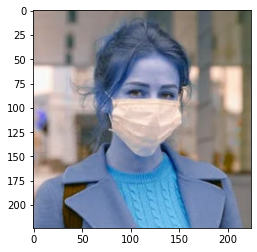

Prediction: 1 ['with_mask']


In [ ]:
from keras.preprocessing.image import load_img
# load the image
testImg="811.jpg"
testImgFPath="./dataset/output/unlabelled/"+testImg

# model allowable image dimensions
img_width, img_height = 224, 224
# loading the image

myImg = cv2.imread(testImgFPath)
# resizing the image
myImg = cv2.resize(myImg, (img_width, img_height))
# coverting BGR to RGB format
myImg1 = cv2.cvtColor(myImg, cv2.COLOR_BGR2RGB)
# adding a new axis [batch axis]
myImg1 = myImg1[np.newaxis, ...]
# rescale image from [0,255] to [0,1]
#myImg = myImg / 255.
# predicting the output
#prediction = model.predict(image)
    
preds = model_new.predict((myImg1))
plt.imshow(myImg)
plt.show()
pred = np.argmax(preds)

#predicted_class_indices=np.argmax(pred,axis=1)

prediction = [classLabelsDict[k] for k in [pred]]
print("Prediction:",pred,prediction)

In [ ]:
explanation = explainer.explain_instance(myImg, model_new.predict,  
                                         top_labels=2, hide_color=0, num_samples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 223.5, 223.5, -0.5)

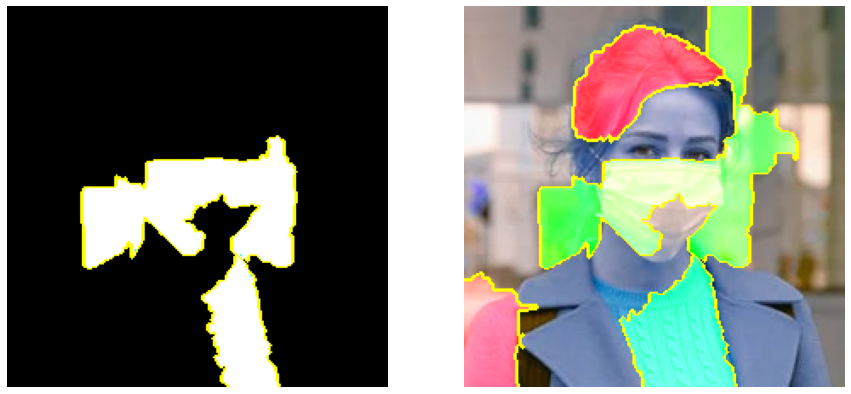

In [ ]:
from skimage.segmentation import mark_boundaries

temp_1, mask_1 = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
temp_2, mask_2 = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,15))
ax1.imshow(mark_boundaries(temp_1, mask_1))
ax2.imshow(mark_boundaries(temp_2, mask_2))
ax1.axis('off')
ax2.axis('off')